# Inverted Pendulum Example

This is an example file that shows how to experiment and create stabilizing controllers for the inverted pendulum
dynamical system. This program is broken into 3 parts:

1) Initializing the pendulum at equilibrium with a controller that outputs arbitrarily small but constant disturbance.
   Here, the user should be able to follow the trajectory plot and use their intuition to see that the pendulum is
   falling away from equilibrium and swinging.

2) Initializing the pendulum slightly away from the equilibrium but using an LQR controller to stabilize it back towards
   the equilibrium. The LQR solution returns a controller in state feedback form as well as a
   quadratic Lyapunov function. For state samples near the equilibrium, it should be visually clear that this Lyapunov
   function fulfills the stability conditions.

3) Initializing the pendulum slightly away from the equilibrium but using a neural network (NN) controller in feedback
   configuration. The NN is fit onto the previous LQR controller before being implemented. Notice that this controller is stabilizing, but it does not get our system exactly to equilibrium

# Dynamics

The dynamics can be described as follows:
$$
\begin{bmatrix}\dot{\theta} \\ \ddot{\theta}\end{bmatrix}
=
\begin{bmatrix}
\dot{\theta} \\ \frac{g}{l}\sin(\theta) - \frac{b\dot{\theta}}{ml^2} + \frac{u}{ml^2}
\end{bmatrix}
$$
where $g$ is gravity, $l$ is the length of the pendulum, $m$ is its mass, $b$ is the damping factor, and $u$ is the control input. The states themselves are $\begin{bmatrix}\theta & \dot{\theta} & \ddot{\theta}\end{bmatrix}$ which represent the pendulum's angular orientation, velocity, and acceleration, respectively.

In [70]:
# imports
from neural_lyapunov_training.pendulum import PendulumDynamics
from neural_lyapunov_training.dynamical_system import SecondOrderDiscreteTimeSystem, IntegrationMethod
import scipy
import numpy as np
from numpy import ndarray
import torch
import torch.nn as nn
from torch import Tensor
from typing import Union, Tuple, Optional
import matplotlib.pyplot as plt
from math import ceil

In [71]:
# additional helpers
# torch default options
set_t = {
    "dtype": torch.float32,
    "device": torch.device("cpu"),  # set to cpu if you don't have a graphics card
}
save_path = "inverted_pendulum_plots/"
show = True   # True if we want to display the plots in the notebook
save = False  # True if we want to save the plots as well as .png files
# integration methods for state evolution
position_integration, velocity_integration = IntegrationMethod.ExplicitEuler, IntegrationMethod.ExplicitEuler

to_numpy = lambda x : x.detach().cpu().numpy() if isinstance(x, Tensor) else x  # converts Tensor to Numpy array

In [72]:
# Our dynamic parameters spelled out for clearer context
dynamic_parameters = {
    "mass": 0.15,
    "length": 0.5,
    "damping": 0.1,
    "time_step": 0.01,
    "time_horizon": 10
}

In [73]:
# basic neural network architecture
class SimpleNNController(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):

        super(SimpleNNController, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, out_dim),
        )

    def forward(self, x):
        return self.model(x)

In [74]:
def plot_states(
        t: Union[Tensor, ndarray],
        x: [Tensor, ndarray],
        title: str,
        y_labels: Optional[list[str]] = None,
        equilibrium_points: Optional[Union[Tensor, ndarray]] = None,
        show: bool = False,
        save_name: Optional[str] = None,
        max_cols: int = 4,
        max_subplots: int = 12
):
    """
    Plots the state trajectories for some dynamical system.
    :param t:               Array of timesteps
    :param x:               State trajectories, 1st dim is time, 2nd dim are states
    :param title:           The suptitle of the plot
    :param y_labels:        Descriptors for the states
    :param show:            True if the plot should be shown
    :param save_name:       If not None, saves the plot with the specified file name
    :param max_cols:        Maximum number of columns in the plot
    :param max_subplots:    Maximum number of subplots to handle
    :return:
    """

    assert len(x.shape) == 2, "States should be two dimensional arrays"

    # Convert to numpy arrays
    if isinstance(t, Tensor):
        t = to_numpy(t)
    if isinstance(x, Tensor):
        x = to_numpy(x)
    if equilibrium_points is not None and isinstance(equilibrium_points, Tensor):
        equilibrium_points = to_numpy(equilibrium_points)

    # handles subplot formatting for arbitrary number of state dimensions
    n_dim = x.shape[1]
    fig = plt.figure(figsize=(12, 8))
    fig.suptitle(title)
    cols = max_cols
    plot_batches = min(n_dim, max_subplots)
    if plot_batches <= cols:
        cols = plot_batches
        rows = 1
    else:
        rows = ceil(plot_batches / cols)
    # subplot offset where first digit are total rows, second digit are total columns, third digit is current subplot
    base_subplot = rows * 100 + cols * 10
    axes = [(i, fig.add_subplot(base_subplot + i + 1)) for i in range(n_dim)]

    for i, ax in axes:
        ax.plot(t, x[:, i])
        ax.set_xlabel("Time")
        if y_labels is not None:
            ax.set_ylabel(y_labels[i])
        else:
            ax.set_ylabel(f"State {i}")
        if equilibrium_points is not None:
            ax.axhline(y=equilibrium_points[i], color='r', linestyle='--', linewidth=1, label='Equilibrium')
            ax.legend()
        ax.grid()

    plt.tight_layout()  # resize the subplots

    if save_name is not None:
        fig.savefig(save_path + save_name)

    if show:
        plt.show()
    else:
        plt.close()

    return

In [75]:
def linearize_pendulum(pendulum_continuous: PendulumDynamics):
    """
    Uses PyTorch autograd to linearize the pendulum about the equilibrium point.
    This is one alternative to exactly computing the linearization.
    :param pendulum_continuous: Continuous pendulum model
    :return:
    """
    x = torch.tensor([[0.0, 0.0]])
    x.requires_grad = True
    u = torch.tensor([[0.0]])
    u.requires_grad = True
    qddot = pendulum_continuous.forward(x, u)
    A = torch.empty((2, 2))
    B = torch.empty((2, 1))
    A[0, 0] = 0
    A[0, 1] = 1
    B[0, 0] = 0
    A[1], B[1] = torch.autograd.grad(qddot[0, 0], [x, u])
    return A, B

def compute_lqr(pendulum_continuous: PendulumDynamics):
    """
    Computes the LQR controller about some equilibrium point.
    The solution entails a controller in linear feedback form u=Kx
    as well a Lyapunov function in quadratic form V=x^TSx.
    :param pendulum_continuous: Continuous pendulum model
    :return:                    Controller, Lyapunov function
    """
    A, B = linearize_pendulum(pendulum_continuous)
    A_np, B_np = A.detach().numpy(), B.detach().numpy()
    Q = np.eye(2)
    R = np.eye(1) * 100
    S = scipy.linalg.solve_continuous_are(A_np, B_np, Q, R)
    K = np.linalg.solve(R, B_np.T @ S)
    return K, S

def approximate(
        system: nn.Module,
        system_input: Tensor,
        target: Tensor,
        lr: float,
        max_iter: int,
        verbose:bool = False
):
    """
    Fits a neural network controller to an LQR controller
    :param system:          The NN controller to train
    :param system_input:    State samples
    :param target:          Target control for each state sample
    :param lr:              Learning rate
    :param max_iter:        Number of training iterations
    :return:
    """
    optimizer = torch.optim.Adam(system.parameters(), lr=lr)
    losses = np.zeros(max_iter)
    for i in range(max_iter):
        optimizer.zero_grad()
        output = torch.nn.MSELoss()(system.forward(system_input), target)
        if verbose: print(f"iter {i}, loss {output.item()}")
        losses[i] = output.item()
        output.backward()
        optimizer.step()

    return losses

In [76]:
# get dynamic parameters
m = dynamic_parameters["mass"]
l = dynamic_parameters["length"]
beta = dynamic_parameters["damping"]
dt = dynamic_parameters["time_step"]
T = dynamic_parameters["time_horizon"]

# initialize the dynamical system
pendulum_continuous = PendulumDynamics(m=m, l=l, beta=beta)
dynamics = SecondOrderDiscreteTimeSystem(
    pendulum_continuous,
    dt=dt,
    position_integration=position_integration,
    velocity_integration=velocity_integration,
)

n_dim = pendulum_continuous.nx  # state dimension
m_dim = pendulum_continuous.nu  # controller dimension

time_steps = torch.arange(0, T, dt)  # time steps
n_time_steps = len(time_steps)

## 1.) Constant Disturbance
Here, we illustrate how the system evolves where the controller simply functions as an input to the system that introduces constant disturbance.


time 0.01 sec | state [0.0000000e+00 3.1789142e-08] | input [[1.1920929e-07]]
time 0.02 sec | state [3.178914e-10 6.273058e-08] | input [[1.1920929e-07]]
time 0.03 sec | state [9.4519714e-10 9.2909275e-08] | input [[1.1920929e-07]]
time 0.04 sec | state [1.8742898e-09 1.2240628e-07] | input [[1.1920929e-07]]
time 0.05 sec | state [3.0983527e-09 1.5129899e-07] | input [[1.1920929e-07]]
time 0.06 sec | state [4.6113424e-09 1.7966138e-07] | input [[1.1920929e-07]]
time 0.07 sec | state [6.4079564e-09 2.0756430e-07] | input [[1.1920929e-07]]
time 0.08 sec | state [8.4835996e-09 2.3507563e-07] | input [[1.1920929e-07]]
time 0.09 sec | state [1.0834356e-08 2.6226058e-07] | input [[1.1920929e-07]]
time 0.10 sec | state [1.3456962e-08 2.8918180e-07] | input [[1.1920929e-07]]
time 0.11 sec | state [1.6348780e-08 3.1589968e-07] | input [[1.1920929e-07]]
time 0.12 sec | state [1.9507777e-08 3.4247248e-07] | input [[1.1920929e-07]]
time 0.13 sec | state [2.2932502e-08 3.6895645e-07] | input [[1.19

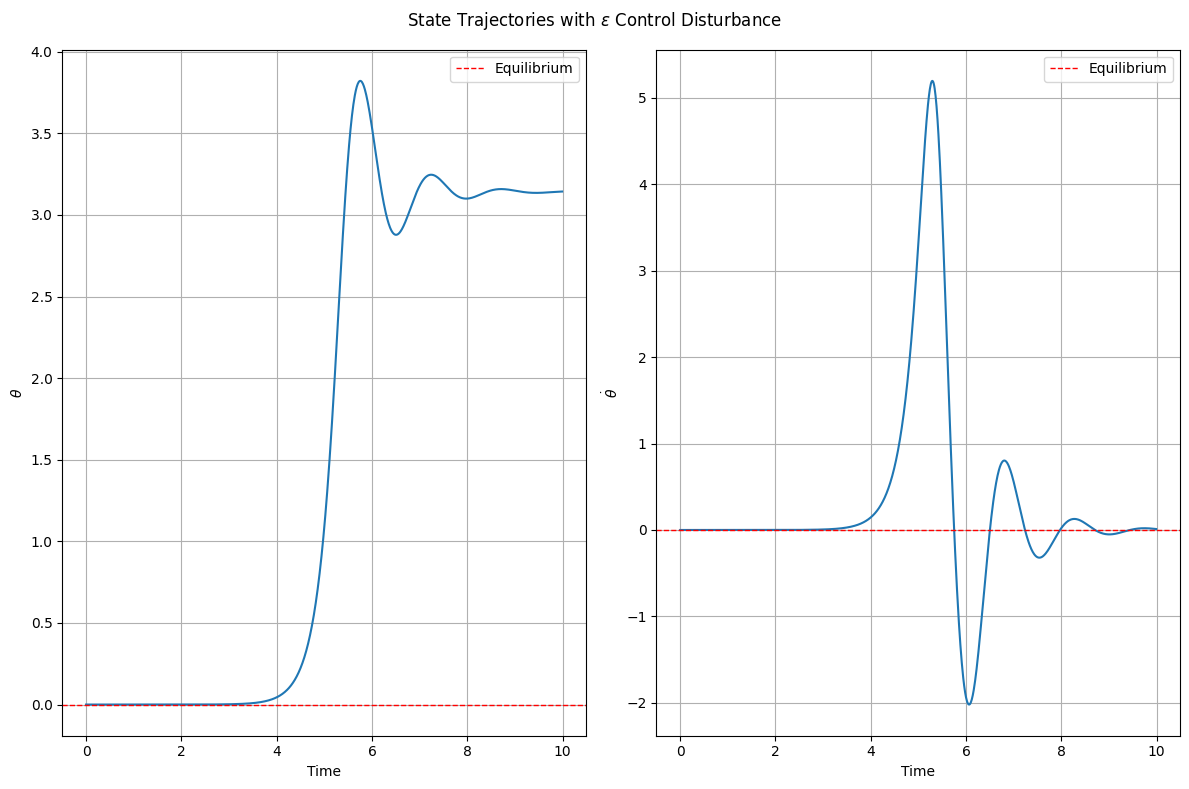

In [77]:
states = torch.zeros((n_time_steps, n_dim), **set_t)
u = torch.full((n_time_steps, m_dim), torch.finfo(set_t["dtype"]).eps, **set_t)
# simulate dynamics
for i in range(1, n_time_steps):
    time = time_steps[i]
    prev_state = states[i-1].unsqueeze(0)
    control = u[i-1].unsqueeze(0)
    new_state = dynamics.forward(prev_state, control).squeeze()
    states[i] = new_state
    print(f"time {time:.2f} sec | state {to_numpy(new_state)} | input {to_numpy(control)}")

# plot results
plot_states(time_steps, states, r"State Trajectories with $\epsilon$ Control Disturbance",
            [r"$\theta$", r"$\dot{\theta}$"], pendulum_continuous.x_equilibrium,
            show, "const_perturbed_control.png" if save else None)

## 2.) LQR Stabilization
We illustrate how the system may be stabilized near the equilibrium point via a controller designed through LQR.

K shape: torch.Size([1, 2]), V shape: torch.Size([101, 1])


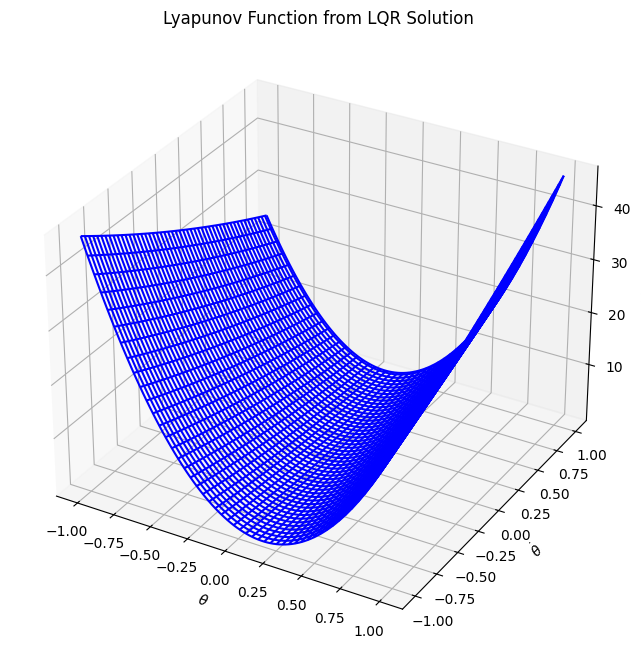

time 0.01 sec | state [0.7759048  0.26605743] | input [[-1.265432]]
time 0.02 sec | state [0.77856535 0.07193744] | input [[-1.2166357]]
time 0.03 sec | state [ 0.7792847  -0.10413265] | input [[-1.169756]]
time 0.04 sec | state [ 0.77824336 -0.26340055] | input [[-1.1247315]]
time 0.05 sec | state [ 0.7756094  -0.40703893] | input [[-1.0815022]]
time 0.06 sec | state [ 0.771539  -0.5361508] | input [[-1.0400097]]
time 0.07 sec | state [ 0.7661775  -0.65177417] | input [[-1.0001965]]
time 0.08 sec | state [ 0.7596597 -0.7548859] | input [[-0.96200514]]
time 0.09 sec | state [ 0.75211084 -0.84640557] | input [[-0.92537975]]
time 0.10 sec | state [ 0.7436468 -0.9271983] | input [[-0.8902644]]
time 0.11 sec | state [ 0.7343748 -0.998078 ] | input [[-0.8566041]]
time 0.12 sec | state [ 0.724394  -1.0598094] | input [[-0.8243442]]
time 0.13 sec | state [ 0.7137959 -1.1131113] | input [[-0.7934311]]
time 0.14 sec | state [ 0.7026648 -1.1586578] | input [[-0.763812]]
time 0.15 sec | state [ 0

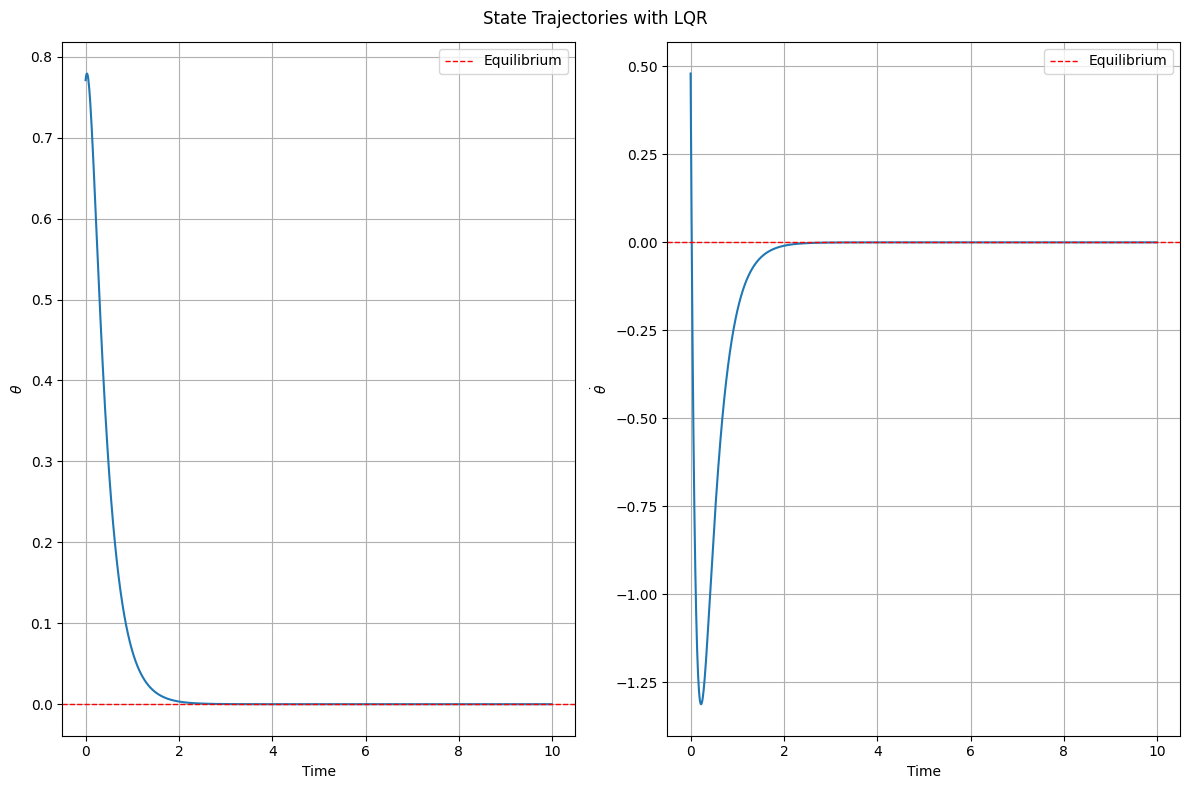

In [78]:
K, S = compute_lqr(pendulum_continuous)
# convert to Tensors
K = torch.from_numpy(K).to(**set_t)  # linear feedback controller
S = torch.from_numpy(S).to(**set_t)  # quadratic Lyapunov function
x = (torch.rand((100, 2), **set_t) - 0.5) * 2  # create a bunch of state samples near the origin to stabilize
x = torch.cat([x, torch.zeros((1, 2), **set_t)], dim=0)  # make sure to include the equilibrium
V = torch.sum(x * (x @ S), axis=1, keepdim=True)
print(f"K shape: {K.shape}, V shape: {V.shape}")

# plot the output of the Lyapunov function for these samples
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
x_np = np.linspace(-1, 1, 100)
y_np = np.linspace(-1, 1, 100)
x_np, y_np = np.meshgrid(x_np, y_np)
lqr_lya = lambda x: np.sum(x * (x @ to_numpy(S)), axis=1)  # applies Lyapunov function to state inputs
V_np = lqr_lya(np.concatenate([x_np.ravel().reshape(-1, 1), y_np.ravel().reshape(-1, 1)], axis=1))
V_np = V_np.reshape(x_np.shape)
ax.plot_wireframe(x_np, y_np, V_np, color='b')
ax.set_title("Lyapunov Function from LQR Solution")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot{\theta}$")
ax.set_zlabel(r"$V(x)$")
if save: plt.savefig(save_path + "lqr_quadratic_lyapunov_function.png")
plt.show() if show else plt.close()

# now initialize the states with some disturbance
std = torch.tensor([torch.pi/4, torch.pi/4])
noise = torch.normal(pendulum_continuous.x_equilibrium, std)
# disturbance = torch.tensor([1e-3, -1e-3], **set_t).reshape(1, -1)
states = torch.empty((n_time_steps, n_dim), **set_t)
states[0, :] = noise
# simulate dynamics
for i in range(1, n_time_steps):
    time = time_steps[i]
    prev_state = states[i - 1]
    x_bar = (prev_state - pendulum_continuous.x_equilibrium).reshape(2, 1)
    control = -K @ x_bar
    new_state = dynamics.forward(prev_state.unsqueeze(0), control).squeeze()
    states[i] = new_state
    print(f"time {time:.2f} sec | state {to_numpy(new_state)} | input {to_numpy(control)}")

# plot results
plot_states(time_steps, states, r"State Trajectories with LQR",
            [r"$\theta$", r"$\dot{\theta}$"], pendulum_continuous.x_equilibrium,
            show, "lqr_control.png" if save else None)

## 3.) NN Control
We illustrate how a NN can be used to learn the LQR controller and replace the LQR controller itself.

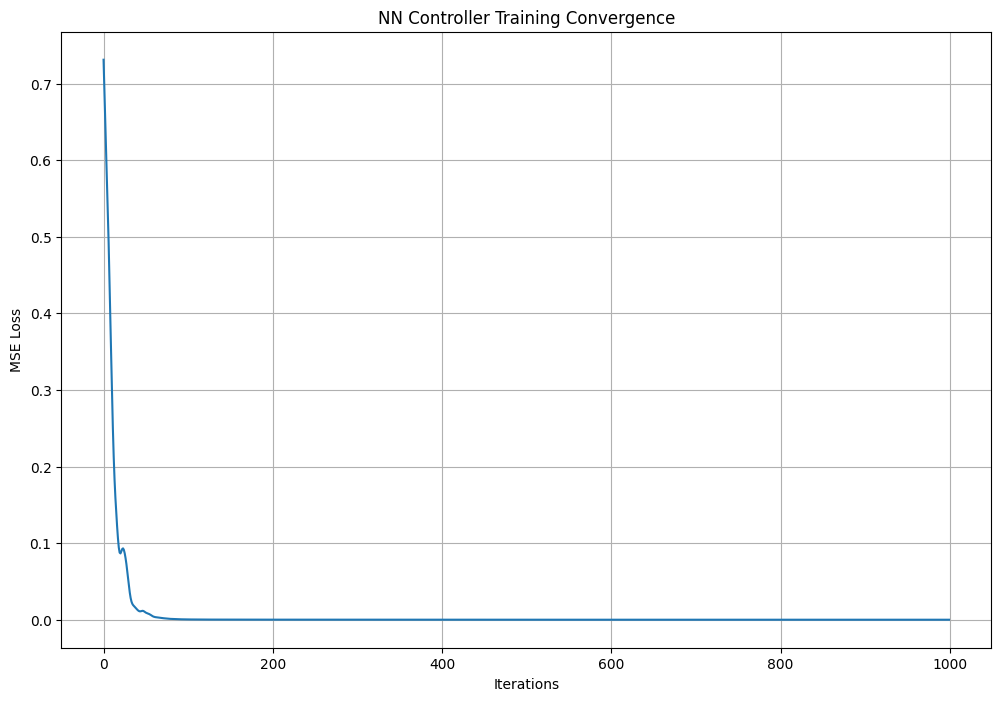

time 0.01 sec | state [0.7759048 0.2657572] | input [[-1.2665578]]
time 0.02 sec | state [0.77856237 0.07149436] | input [[-1.2172015]]
time 0.03 sec | state [ 0.7792773  -0.10458875] | input [[-1.1698476]]
time 0.04 sec | state [ 0.77823144 -0.2637641 ] | input [[-1.1244262]]
time 0.05 sec | state [ 0.7755938  -0.40722585] | input [[-1.0808699]]
time 0.06 sec | state [ 0.77152157 -0.53609574] | input [[-1.0391128]]
time 0.07 sec | state [ 0.7661606 -0.6517405] | input [[-1.000262]]
time 0.08 sec | state [ 0.7596432 -0.7549497] | input [[-0.96235824]]
time 0.09 sec | state [ 0.7520937 -0.8466235] | input [[-0.9259553]]
time 0.10 sec | state [ 0.7436274 -0.9276102] | input [[-0.89100444]]
time 0.11 sec | state [ 0.73435134 -0.9987093 ] | input [[-0.85745764]]
time 0.12 sec | state [ 0.7243642 -1.0606735] | input [[-0.8252667]]
time 0.13 sec | state [ 0.7137575 -1.1142108] | input [[-0.794384]]
time 0.14 sec | state [ 0.7026154 -1.1599977] | input [[-0.76480186]]
time 0.15 sec | state [ 

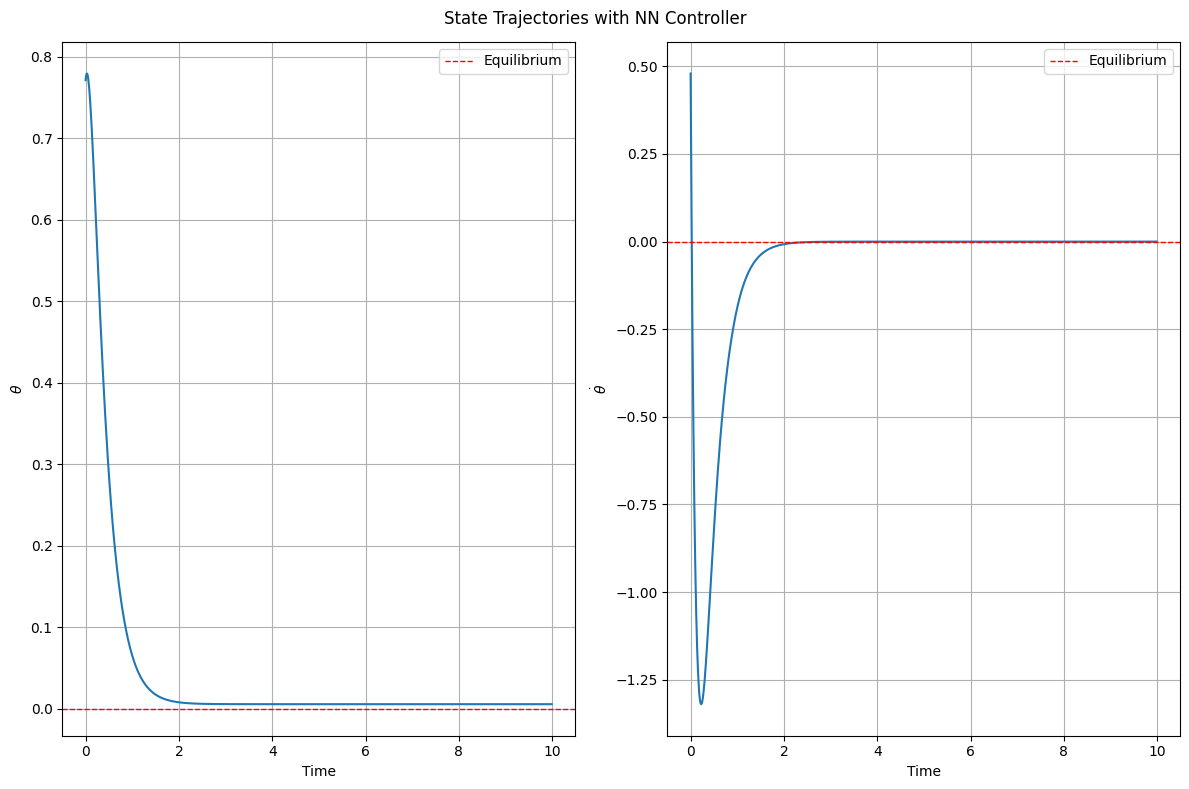

In [81]:
x = (torch.rand((100000, 2), **set_t) - 0.5) * 2  # create a bunch of state samples near the origin to stabilize
x = torch.cat([x, torch.zeros((1, 2), **set_t)], dim=0)  # make sure to include the equilibrium
lqr_samples = torch.einsum('ij,bj->bi', -K, (x - pendulum_continuous.x_equilibrium.unsqueeze(0)))
# lqr_samples = x @ K.permute(1, 0)  # get the control feedback for these states
controller = SimpleNNController(n_dim, m_dim).to(device=set_t["device"])  # initialize a simple NN controller
losses = approximate(controller, x, lqr_samples, lr=0.01, max_iter=1000)  # fit the NN to the LQR controller

# plot the training loss
plt.figure(figsize=(12, 8))
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("NN Controller Training Convergence")
plt.grid()
if save: plt.savefig(save_path + "nn_controller_loss.png")
plt.show() if show else plt.close()

# now initialize the states with some disturbance
# states = (torch.rand((n_time_steps, n_dim), **set_t) - 0.5) * 2
states = torch.empty((n_time_steps, n_dim), **set_t)
states[0, :] = noise
# simulate dynamics
for i in range(1, n_time_steps):
    time = time_steps[i]
    prev_state = states[i - 1].unsqueeze(0)
    x_bar = (prev_state - pendulum_continuous.x_equilibrium.unsqueeze(0))
    control = controller(x_bar)
    new_state = dynamics.forward(prev_state, control).squeeze()
    states[i] = new_state
    print(f"time {time:.2f} sec | state {to_numpy(new_state)} | input {to_numpy(control)}")

# plot results
plot_states(time_steps, states, r"State Trajectories with NN Controller",
            [r"$\theta$", r"$\dot{\theta}$"], pendulum_continuous.x_equilibrium,
            show, "nn_control.png" if save else None)

# Zubov's PDE

In this section, we will now experiment with using a NN to learn a maximal Lyapunov function on the inverted pendulum problem with an LQR controller.

In [ ]:
# imports related to Zubov PDE training
from SimpleExamples.zubov.architecture import *
from SimpleExamples.zubov.dataset import *